# BERT-based Analysis of UberPeople.net Forum Data
This notebook performs advanced analysis of forum discussions to understand:
- Driver resistance strategies against algorithmic management
- Evolution of collective action patterns
- Platform-driver interaction dynamics
## Setup Instructions
Run the following cells to install required packages and initialize the environment.

In [4]:
# Package Installation
!pip install transformers torch pandas numpy bertopic umap-learn hdbscan plotly tqdm nltk seaborn openpyxl
# umap-learn: for dimensionality reduction
# hdbscan: for clustering

In [29]:
# Import Libraries abd Constants

# Core data processing
import pandas as pd
import numpy as np
import torch  # For deep learning operations

# BERT and topic modeling
from transformers import AutoTokenizer, AutoModel
from bertopic import BERTopic
from umap import UMAP   # For dimensionality reduction
from hdbscan import HDBSCAN   # For clustering

# Visualization
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Text processing
import nltk
from nltk.tokenize import sent_tokenize
import re

# Utility
import os
import logging
import warnings
from tqdm.auto import tqdm    # For progress bars

# Mischellous
from sklearn.feature_extraction.text import CountVectorizer
import plotly.graph_objects as go
from google.colab import drive, output
from datetime import datetime
from IPython.display import display, HTML


# Adjust this path to match your Google Drive structure
BASE_FOLDER_PATH = '/content/drive/MyDrive/ColabNotebooks/uber-forum-analysis'
BASE_DATA_PATH = '/content/drive/MyDrive/ColabNotebooks/uber-forum-analysis/data'


# Configure settings
warnings.filterwarnings('ignore')   # Suppress warnings
nltk.download('punkt')              # Download tokenizer data
nltk.download('stopwords')          # Download stopwords
print("Available styles:", plt.style.available)
plt.style.use('seaborn-v0_8')

# plt.style.use('seaborn')
logging.basicConfig(level=logging.INFO)

# Enable dynamic output for Colab
output.enable_custom_widget_manager()

# Check GPU availability and set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"Available GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Available styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
Using device: cpu


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [30]:
# Constant var

# Adjust this path to match your Google Drive structure
BASE_FOLDER_PATH = '/content/drive/MyDrive/ColabNotebooks/uber-forum-analysis'
BASE_DATA_PATH = '/content/drive/MyDrive/ColabNotebooks/uber-forum-analysis/data'


In [31]:
# Define Helper Functions
def clean_text(text):
    """Clean and preprocess text data"""
    text = str(text)  # Ensure text is string
    text = re.sub(r'http\S+|www.\S+', '', text)  # Remove URLs
    text = re.sub(r'[^\w\s]', '', text)  # Remove special characters
    text = ' '.join(text.split())  # Remove extra whitespace
    return text.lower()

def save_to_drive(data, filename, folder_path='BERTAnalysis'):
    """Save data to specific folder in Google Drive"""
    full_path = f'{BASE_FOLDER_PATH}/{folder_path}/{filename}'
    try:
        # Create folder if it doesn't exist
        !mkdir -p "{BASE_FOLDER_PATH}/{folder_path}"

        # Save based on file type
        if isinstance(data, pd.DataFrame):
            data.to_csv(full_path)
        elif isinstance(data, dict):
            np.save(full_path, data)
        elif isinstance(data, plt.Figure):
            data.savefig(full_path)
        else:
            with open(full_path, 'wb') as f:
                np.save(f, data)
        print(f"Successfully saved {filename} to Drive")
    except Exception as e:
        print(f"Error saving {filename}: {str(e)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting data loading process...
Attempting to load data from: /content/drive/MyDrive/ColabNotebooks/uber-forum-analysis/data

Contents of the directory:
- 2017
- .DS_Store
- 2018
- 2019
- 2020
- 2022
- 2025
- 2016
- 2024
- 2023
- 2014
- 2015
- 2021
Found 12 potential year folders: ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
Processing 12 year folders within the range 2014-2025: ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


Processing years:   0%|          | 0/12 [00:00<?, ?it/s]


Processing 2014: Found 9 files


Loading files from 2014:   0%|          | 0/9 [00:00<?, ?it/s]

Loaded 2014-4.xlsx: 103 rows
Loaded 2014-6.xlsx: 241 rows
Loaded 2014-5.xlsx: 196 rows
Loaded 2014-7.xlsx: 418 rows
Loaded 2014-8.xlsx: 1102 rows
Loaded 2014-9.xlsx: 1309 rows
Loaded 2014-10.xlsx: 1285 rows
Loaded 2014-11.xlsx: 1533 rows
Loaded 2014-12.xlsx: 1624 rows

Processing 2015: Found 12 files


...

Loaded 2024-1.xlsx: 806 rows
Loaded 2024-3.xlsx: 586 rows
Loaded 2024-4.xlsx: 562 rows
Loaded 2024-2.xlsx: 728 rows
Loaded 2024-5.xlsx: 646 rows
Loaded 2024-8.xlsx: 580 rows
Loaded 2024-7.xlsx: 640 rows
Loaded 2024-6.xlsx: 586 rows
Loaded 2024-9.xlsx: 525 rows
Loaded 2024-12.xlsx: 534 rows
Loaded 2024-10.xlsx: 578 rows
Loaded 2024-11.xlsx: 522 rows

Processing 2025: Found 6 files


Loading files from 2025:   0%|          | 0/6 [00:00<?, ?it/s]

Loaded 2025-1.xlsx: 400 rows
Loaded 2025-5.xlsx: 85 rows
Error loading ~$2025-1.xlsx: Excel file format cannot be determined, you must specify an engine manually.
Loaded 2025-3.xlsx: 310 rows
Loaded 2025-4.xlsx: 220 rows
Loaded 2025-2.xlsx: 318 rows

Data Loading Summary:
Total files processed: 134
Total rows: 385149
Date range: 2014-04-09 00:00:00 to 2025-05-14 00:00:00

Columns in the dataset:
- id: object
- date: datetime64[ns]
- title: object
- content: object
- algoactivism_type: object
- author: object
- forum: object
- views: int64
- reactions_amount: int64
- comments_amount: int64
- sentiment: float64
- source_year: object
- source_file: object

Dataset Summary:


Metric,Value
Total Posts,385149
Date Range,2014-04-09 to 2025-05-14
Unique Authors,50769
Years Covered,12
Average Posts per Year,"32,095.8"


Successfully saved preprocessed_data.csv to Drive


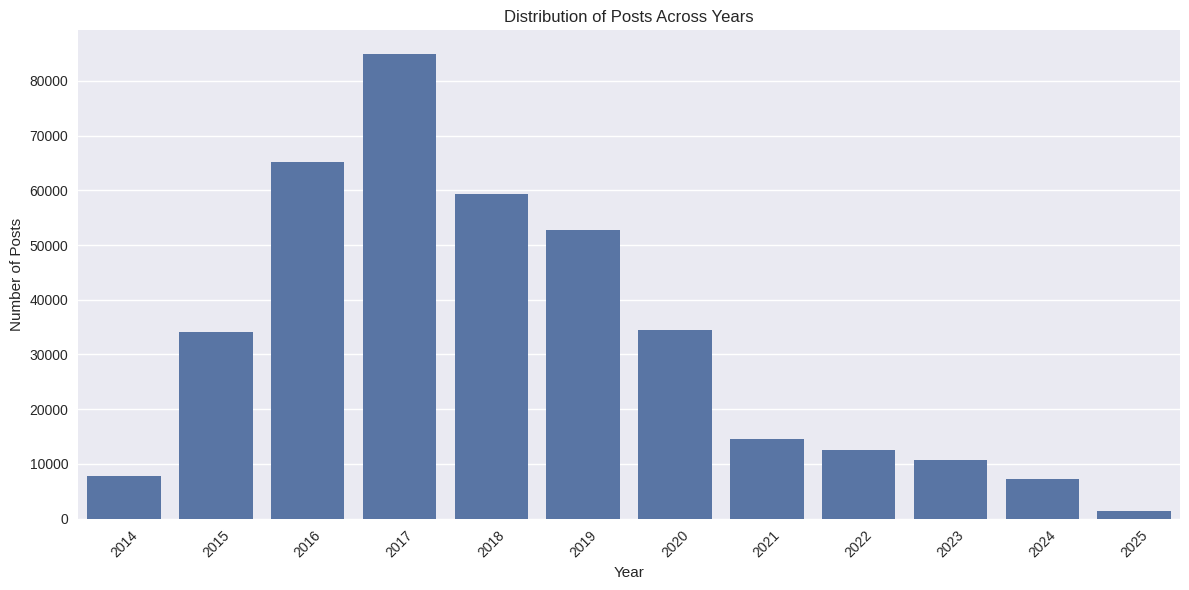

In [32]:
# Data Loading and Combination

# Mount Google Drive
drive.mount('/content/drive')

def load_uber_data(base_path):
    """
    Load data from multiple Excel files in year folders

    Parameters:
    base_path: Path to the main data folder containing year folders

    Returns:
    Combined DataFrame of all Excel files
    """

    print(f"Attempting to load data from: {base_path}")

    # First, verify the path exists
    if not os.path.exists(base_path):
        raise Exception(f"Path does not exist: {base_path}")

    # List and print the contents of the directory
    print("\nContents of the directory:")
    try:
        for item in os.listdir(base_path):
            print(f"- {item}")
    except Exception as e:
        print(f"Error listing directory contents: {str(e)}")


    all_data = []  # List to store DataFrames from each file

    # Get list of year folders (assuming they are subdirectories within base_path and are digits)
    year_folders = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f)) and f.isdigit()])

    if not year_folders:
        raise Exception(f"No year folders (2014-2025) found in {base_path}")

    print(f"Found {len(year_folders)} potential year folders: {year_folders}")

    # Filter year folders to be within the desired range (2014-2025)
    valid_year_folders = [folder for folder in year_folders if 2014 <= int(folder) <= 2025]
    valid_year_folders.sort() # Ensure chronological order

    if not valid_year_folders:
        raise Exception(f"No year folders found within the range 2014-2025 in {base_path}")

    print(f"Processing {len(valid_year_folders)} year folders within the range 2014-2025: {valid_year_folders}")


    # Iterate through each valid year folder
    for year in tqdm(valid_year_folders, desc="Processing years"):
        year_path = os.path.join(base_path, year)

        # Get all Excel files in the year folder
        excel_files = [f for f in os.listdir(year_path) if f.endswith('.xlsx')]

        print(f"\nProcessing {year}: Found {len(excel_files)} files")

        # Load each Excel file in the year folder
        for file in tqdm(excel_files, desc=f"Loading files from {year}"):
            file_path = os.path.join(year_path, file)
            try:
                # Read the Excel file
                df = pd.read_excel(file_path)

                # Add year and file information
                df['source_year'] = year
                df['source_file'] = file

                all_data.append(df)
                print(f"Loaded {file}: {len(df)} rows")

            except Exception as e:
                print(f"Error loading {file}: {str(e)}")

    # Combine all DataFrames
    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        print("\nData Loading Summary:")
        print(f"Total files processed: {len(all_data)}")
        print(f"Total rows: {len(combined_df)}")

        # Ensure 'date' column exists and is in datetime format before trying to find min/max
        if 'date' in combined_df.columns and pd.api.types.is_datetime64_any_dtype(combined_df['date']):
             print(f"Date range: {combined_df['date'].min()} to {combined_df['date'].max()}")
        else:
             print("Date range: 'date' column not found or not in datetime format.")


        print("\nColumns in the dataset:")
        for col in combined_df.columns:
            print(f"- {col}: {combined_df[col].dtype}")

        return combined_df
    else:
        raise Exception("No data was loaded!")

# Mount Google Drove
from google.colab import drive
drive.mount('/content/drive')

# Load the data
try:
    # Adjust this path to match your Google Drive structure
    BASE_DATA_PATH = '/content/drive/MyDrive/ColabNotebooks/uber-forum-analysis/data'

    print("Starting data loading process...")
    df = load_uber_data(BASE_DATA_PATH)

    # Basic preprocessing
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['full_text'] = df['title'].fillna('') + ' ' + df['content'].fillna('')
    df['clean_text'] = df['full_text'].apply(clean_text)

    # Display basic information with Colab formatting
    from IPython.display import HTML, display
    import matplotlib.pyplot as plt
    import seaborn as sns
    import re

    # Create summary statistics
    summary_stats = pd.DataFrame({
        'Metric': [
            'Total Posts',
            'Date Range',
            'Unique Authors',
            'Years Covered',
            'Average Posts per Year'
        ],
        'Value': [
            len(df),
            f"{df['date'].min().date() if not df['date'].min() is pd.NaT else 'N/A'} to {df['date'].max().date() if not df['date'].max() is pd.NaT else 'N/A'}",
            df['author'].nunique() if 'author' in df.columns else 'N/A',
            len(df['source_year'].unique()) if 'source_year' in df.columns else 'N/A',
            f"{len(df)/len(df['source_year'].unique()):,.1f}" if 'source_year' in df.columns and len(df['source_year'].unique()) > 0 else 'N/A'

        ]
    })

    print("\nDataset Summary:")
    display(HTML(summary_stats.to_html(index=False)))

    # Save preprocessed data
    save_to_drive(df, 'preprocessed_data.csv')

    # Show distribution of posts across years
    if 'source_year' in df.columns:
        plt.figure(figsize=(12, 6))
        year_counts = df['source_year'].value_counts().sort_index()
        sns.barplot(x=year_counts.index, y=year_counts.values)
        plt.title('Distribution of Posts Across Years')
        plt.xlabel('Year')
        plt.ylabel('Number of Posts')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("\n'source_year' column not found, skipping year distribution plot.")

except Exception as e:
    print(f"Error in data loading process: {str(e)}")

In [ ]:
# Initialize BERT Analyzer Class

class BERTAnalyzer:
    """
    A class for analyzing text data using BERT embeddings and topic modeling.
    This class combines BERT's language understanding capabilities with clustering
    for topic identification.
    """
    def __init__(self, model_name='bert-base-uncased'):
        """
        Initialize the BERT Analyzer with model and components for topic modeling.

        Parameters:
        -----------
        model_name : str
            Name of the BERT model to use (default: 'bert-base-uncased')
            Other options include 'bert-large-uncased', 'bert-base-cased', etc.
        """
        # Set up GPU if available, else use CPU
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        # Initialize BERT model components
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)          # Convert text to BERT tokens
        self.model = AutoModel.from_pretrained(model_name).to(self.device)  # Load BERT model

        # Initialize topic modeling components
        # UMAP: Dimensionality reduction technique
        self.umap_model = UMAP(
            neighbors=15,   # Number of neighbors to consider for each point
            n_components=5, # Number of dimensions to reduce to
            min_dist=0.0    # Minimum distance between points
        )

        # HDBSCAN: Clustering algorithm for topic identification
        self.hdbscan_model = HDBSCAN(
            min_cluster_size=15,  # Minimum size of clusters
            metric='euclidean'    # Distance metric for clustering
        )

        # CountVectorizer: Convert text to word frequency vectors
        self.vectorizer = CountVectorizer(
            stop_words="english"  # Remove common English words
        )

    def generate_embeddings(self, texts, batch_size=16):
        """
        Generate BERT embeddings for a list of texts.

        Parameters:
        -----------
        texts : list
            List of text strings to generate embeddings for
        batch_size : int
            Number of texts to process at once (default: 16)

        Returns:
        --------
        numpy.ndarray
            Array of BERT embeddings for each text
        """
        embeddings = []

        for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
            batch_texts = texts[i:i + batch_size]

            # Memory management: Clear GPU cache periodically
            if i % 100 == 0:
                torch.cuda.empty_cache()

            try:
                # Convert texts to BERT input format
                encoded = self.tokenizer(
                    batch_texts, padding=True,  # Add padding to make all sequences same length
                    truncation=True,            # Truncate long sequences
                    max_length=512,             # Maximum sequence length
                    return_tensors='pt'         # Return PyTorch tensors
                )

                # Move data to GPU/CPU
                input_ids = encoded['input_ids'].to(self.device)
                attention_mask = encoded['attention_mask'].to(self.device)

                # Generate embeddings without gradient calculation
                with torch.no_grad():
                    outputs = self.model(input_ids, attention_mask=attention_mask)
                    # Get CLS token embedding (first token) for each text
                    batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                    embeddings.extend(batch_embeddings)

            except RuntimeError as e:
                print(f"Error processing batch {i}: {str(e)}")
                torch.cuda.empty_cache()
                continue

        return np.array(embeddings)